# Import the data

In [ ]:
pip install ucimlrepo

  Using cached ucimlrepo-0.0.7-py3-none-any.whl.metadata (5.5 kB)
Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)


In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

# metadata
print(cdc_diabetes_health_indicators.metadata)

# variable information
print(cdc_diabetes_health_indicators.variables)

{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

# Step 1: Data Wrangling/Cleaning Process

In [ ]:
# import packages
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# print basic features of data
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print(X.head())
print(y.head())

Features shape: (253680, 21)
Target shape: (253680, 1)
   HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  \
0       1         1          1   40       1       0                     0   
1       0         0          0   25       1       0                     0   
2       1         1          1   28       0       0                     0   
3       1         0          1   27       0       0                     0   
4       1         1          1   24       0       0                     0   

   PhysActivity  Fruits  Veggies  ...  AnyHealthcare  NoDocbcCost  GenHlth  \
0             0       0        1  ...              1            0        5   
1             1       0        0  ...              0            1        3   
2             0       1        0  ...              1            1        5   
3             1       1        1  ...              1            0        2   
4             1       1        1  ...              1            0        2   

   MentHlth  

In [ ]:
# concatenate the dataframe
df = pd.concat([X, y], axis=1)
print("Combined shape:", df.shape)
print(df.info())

# do a basic null / missing checks
print("Null values per column:")
print(df.isnull().sum())

# check for unnecessary spaces / empty strings
obj_cols = df.select_dtypes(include="object").columns.tolist()
for col in obj_cols:
    df[col] = df[col].astype(str).str.strip()
    print(f"Empty strings in {col}:", (df[col] == "").sum())

# check duplicates
print("Number of duplicated rows:", df.duplicated().sum())

# drop duplicates
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Combined shape: (253680, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysH

In [ ]:
# drop the ID column
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

# make all feature columns are numeric
df = df.apply(pd.to_numeric)
print(df.dtypes)

HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
Diabetes_binary         int64
dtype: object


In [ ]:
# create list of binary feature columns (0/1)
binary_cols = [
    "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
    "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
    "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost", "DiffWalk"
]

# create list of ordinal but discrete health/demographic variables
ordinal_cols = ["GenHlth", "Age", "Education", "Income"]

target_col = "Diabetes_binary"

# double check these are integers
df[binary_cols + ordinal_cols + [target_col]] = df[binary_cols + ordinal_cols + [target_col]].astype(int)

# Education: convert to a ordered scale (1 = lowest, 6 = highest)
education_map = {
    1: "Never attended school or kindergarten",
    2: "Grades 1-8 (Elementary)",
    3: "Grades 9-11 (Some high school)",
    4: "Grade 12 or GED (High school graduate)",
    5: "College 1-3 years (Some college/technical school)",
    6: "College 4+ years (College graduate)"
}

income_map = {
    1: "< $10,000",
    2: "$10,000 - $14,999",
    3: "$15,000 - $19,999",
    4: "$20,000 - $24,999",
    5: "$25,000 - $34,999",
    6: "$35,000 - $49,999",
    7: "$50,000 - $74,999",
    8: "$75,000 or more"
}

# we decided to keep Education and Income as ordered integers for modeling,
# but these dictionary's document the ordinal meaning
print("Education codes:", education_map)
print("Income codes:", income_map)

Education codes: {1: 'Never attended school or kindergarten', 2: 'Grades 1-8 (Elementary)', 3: 'Grades 9-11 (Some high school)', 4: 'Grade 12 or GED (High school graduate)', 5: 'College 1-3 years (Some college/technical school)', 6: 'College 4+ years (College graduate)'}
Income codes: {1: '< $10,000', 2: '$10,000 - $14,999', 3: '$15,000 - $19,999', 4: '$20,000 - $24,999', 5: '$25,000 - $34,999', 6: '$35,000 - $49,999', 7: '$50,000 - $74,999', 8: '$75,000 or more'}


In [ ]:
# continuous features to standardize (z-score)
continuous_cols = ["BMI", "MentHlth", "PhysHlth"]

scaler = StandardScaler()
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

print("Scaled continuous columns summary:")
print(df[continuous_cols].describe().T)

Scaled continuous columns summary:
             count          mean       std       min       25%       50%  \
BMI       229474.0 -1.622745e-16  1.000002 -2.457953 -0.690437 -0.248558   
MentHlth  229474.0 -2.905776e-17  1.000002 -0.454786 -0.454786 -0.454786   
PhysHlth  229474.0  2.416738e-17  1.000002 -0.517213 -0.517213 -0.517213   

               75%        max  
BMI       0.487907  10.209244  
MentHlth -0.195639   3.432420  
PhysHlth -0.075266   2.797390  


In [ ]:
# create the final, cleaned, wrangled dataframes
X_final = df.drop(columns=[target_col])
y_final = df[target_col]

print("Final X shape:", X_final.shape)
print("Final y shape:", y_final.shape)
print(X_final.head())
print(y_final.value_counts(normalize=True))

Final X shape: (229474, 21)
Final y shape: (229474,)
   HighBP  HighChol  CholCheck       BMI  Smoker  Stroke  \
0       1         1          1  1.666251       1       0   
1       0         0          0 -0.543144       1       0   
2       1         1          1 -0.101265       0       0   
3       1         0          1 -0.248558       0       0   
4       1         1          1 -0.690437       0       0   

   HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  ...  AnyHealthcare  \
0                     0             0       0        1  ...              1   
1                     0             1       0        0  ...              0   
2                     0             0       1        0  ...              1   
3                     0             1       1        1  ...              1   
4                     0             1       1        1  ...              1   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  Age  Education  \
0            0        5  1.877538  1.14

# Step 2: Create the Models

# Model #1: Logisitic Regresion Model

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_recall_curve,
    roc_curve, confusion_matrix, classification_report
)
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

# stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, stratify=y_final, random_state=42
)

# pipeline: scaling + PCA + logistic regression
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('logreg', LogisticRegression(max_iter=500, solver='lbfgs'))
])

# hyperparameter grid
param_grid_lr = {
    'logreg__C': [0.1, 1, 10],
    'logreg__penalty': ['l2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=cv, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)

print("Best Logistic Regression Parameters:", grid_lr.best_params_)
print("Best CV F1 Score:", grid_lr.best_score_)

# evaluate on test
y_pred = grid_lr.predict(X_test)
y_prob = grid_lr.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1:", f1_score(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))


Best Logistic Regression Parameters: {'logreg__C': 10, 'logreg__penalty': 'l2'}
Best CV F1 Score: 0.2224805861949966
Test Accuracy: 0.8512909903039547
Test F1: 0.23185143500281374
Test ROC-AUC: 0.8019069522920172
              precision    recall  f1-score   support

           0       0.86      0.98      0.92     38876
           1       0.55      0.15      0.23      7019

    accuracy                           0.85     45895
   macro avg       0.71      0.56      0.57     45895
weighted avg       0.82      0.85      0.81     45895



/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


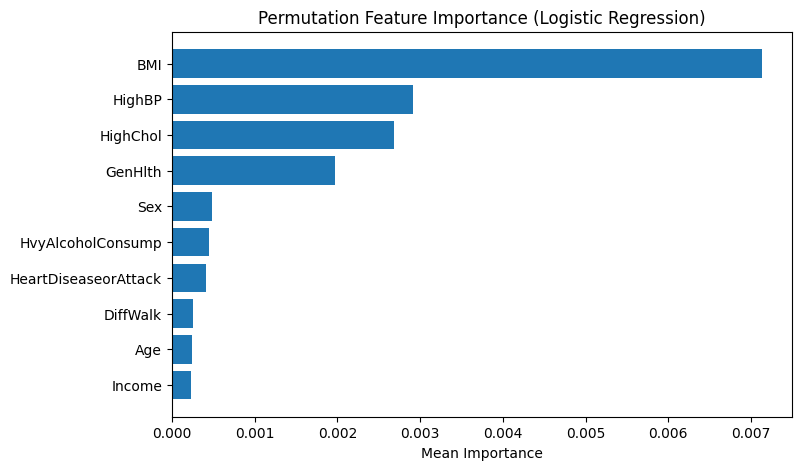

In [ ]:
# calibrate classifier for better probability estimates
cal_lr = CalibratedClassifierCV(grid_lr.best_estimator_, cv='prefit')
cal_lr.fit(X_train, y_train)

y_prob_cal = cal_lr.predict_proba(X_test)[:, 1]

# permutation feature importance
perm_importance = permutation_importance(
    cal_lr, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# visualize top 10 features
sorted_idx = perm_importance.importances_mean.argsort()[-10:]
plt.figure(figsize=(8, 5))
plt.barh(np.array(X_final.columns)[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.title("Permutation Feature Importance (Logistic Regression)")
plt.xlabel("Mean Importance")
plt.show()


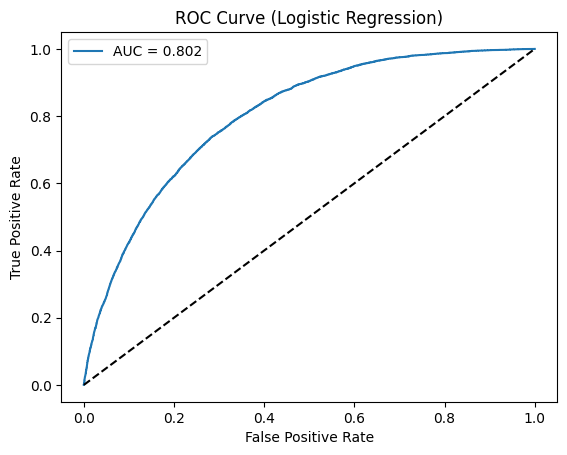

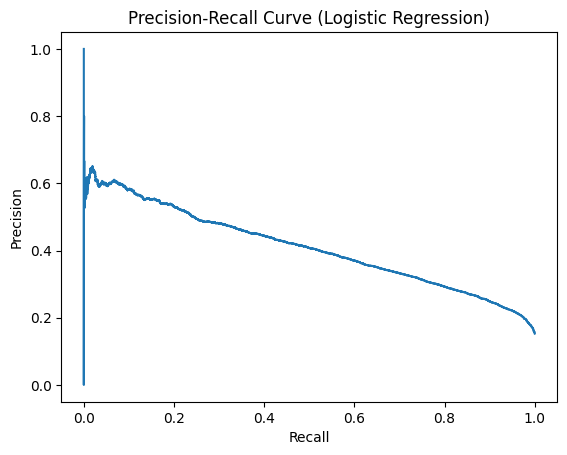

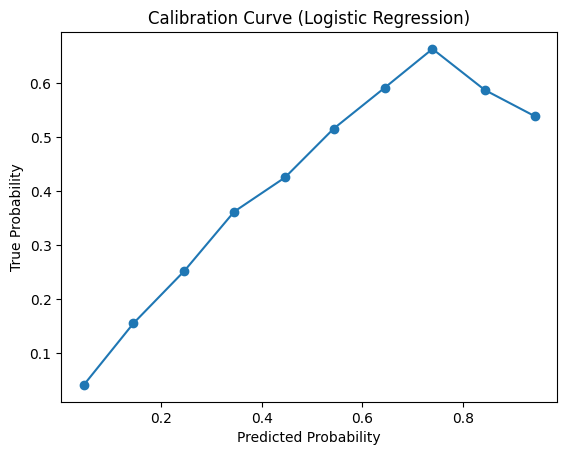

In [ ]:
from sklearn.calibration import calibration_curve

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_cal)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob_cal):.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve (Logistic Regression)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob_cal)
plt.figure()
plt.plot(recall, precision)
plt.title("Precision-Recall Curve (Logistic Regression)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, y_prob_cal, n_bins=10)
plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.title("Calibration Curve (Logistic Regression)")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.show()


# Model #2: k-Nearest Neighbors Model

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    StratifiedShuffleSplit,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    classification_report,
    recall_score
)
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import seaborn as sns

# stratified train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    stratify=y_final,
    random_state=42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Class balance in train:")
print(y_train.value_counts(normalize=True))
print("Class balance in test:")
print(y_test.value_counts(normalize=True))

# small stratified subset for kNN, use ~30% of training data for GridSearchCV, still stratified
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.7, random_state=42)

for small_idx, _ in sss.split(X_train, y_train):
    X_train_small = X_train.iloc[small_idx]
    y_train_small = y_train.iloc[small_idx]

print("Subset for tuning:", X_train_small.shape)

# PCA
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=12, random_state=42)),  # dimensionality reduction
    ('knn', KNeighborsClassifier())
])

# k values
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 10, 15, 20]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    cv=cv,
    scoring='f1',
    n_jobs=1
)

grid_knn.fit(X_train_small, y_train_small)

print("Best kNN Parameters:", grid_knn.best_params_)
print("Best CV F1 Score (kNN):", grid_knn.best_score_)

best_k = grid_knn.best_params_['knn__n_neighbors']

# refit best kNN on full training data
best_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=12, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])

best_knn.fit(X_train, y_train)

# evaluation on test set (accuracy, F1, ROC-AUC, recall)
y_pred_knn = best_knn.predict(X_test)
y_prob_knn = best_knn.predict_proba(X_test)[:, 1]

print("kNN Test Accuracy:", accuracy_score(y_test, y_pred_knn))
print("kNN Test F1:", f1_score(y_test, y_pred_knn))
print("kNN Test Recall:", recall_score(y_test, y_pred_knn))
print("kNN Test ROC-AUC:", roc_auc_score(y_test, y_prob_knn))
print("Classification report (kNN):")
print(classification_report(y_test, y_pred_knn))

# model comparison row
results_knn = pd.DataFrame({
    "Model": ["kNN"],
    "Best_k": [best_k],
    "CV_F1": [grid_knn.best_score_],
    "Test_Accuracy": [accuracy_score(y_test, y_pred_knn)],
    "Test_F1": [f1_score(y_test, y_pred_knn)],
    "Test_Recall": [recall_score(y_test, y_pred_knn)],
    "Test_ROC_AUC": [roc_auc_score(y_test, y_prob_knn)]
})
print(results_knn)


Train shape: (183579, 21)  Test shape: (45895, 21)
Class balance in train:
Diabetes_binary
0    0.847052
1    0.152948
Name: proportion, dtype: float64
Class balance in test:
Diabetes_binary
0    0.847064
1    0.152936
Name: proportion, dtype: float64
Subset for tuning: (55073, 21)
Best kNN Parameters: {'knn__n_neighbors': 3}
Best CV F1 Score (kNN): 0.2759033654506052
kNN Test Accuracy: 0.8191306242510077
kNN Test F1: 0.29117923319955596
kNN Test Recall: 0.24291209574013392
kNN Test ROC-AUC: 0.6661431872458952
Classification report (kNN):
              precision    recall  f1-score   support

           0       0.87      0.92      0.90     38876
           1       0.36      0.24      0.29      7019

    accuracy                           0.82     45895
   macro avg       0.62      0.58      0.59     45895
weighted avg       0.79      0.82      0.80     45895

  Model  Best_k     CV_F1  Test_Accuracy   Test_F1  Test_Recall  Test_ROC_AUC
0   kNN       3  0.275903       0.819131  0.291179

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
# calibration
cal_knn = CalibratedClassifierCV(
    estimator=best_knn,
    cv=3,
    method='sigmoid'
)

cal_knn.fit(X_train, y_train)
y_prob_knn_cal = cal_knn.predict_proba(X_test)[:, 1]

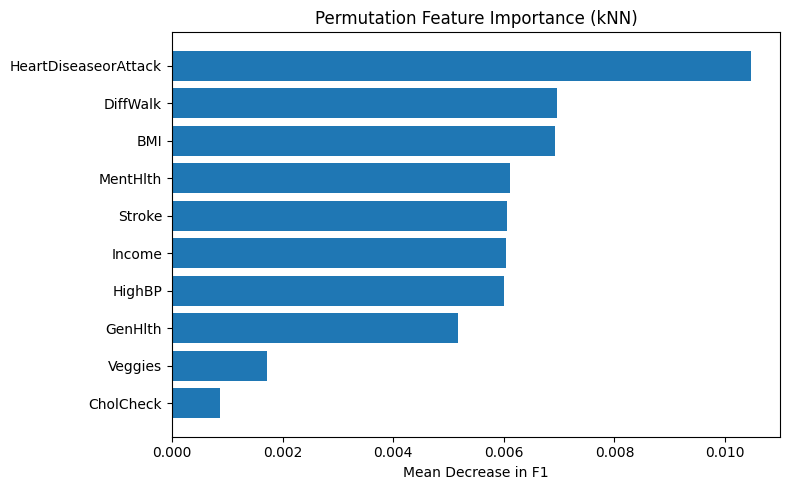

In [ ]:
# permutation
if len(X_test) > 5000:
    test_sample = X_test.sample(n=5000, random_state=42)
    y_test_sample = y_test.loc[test_sample.index]
else:
    test_sample = X_test
    y_test_sample = y_test

perm_knn = permutation_importance(
    estimator=cal_knn,
    X=test_sample,
    y=y_test_sample,
    n_repeats=3,
    random_state=42,
    n_jobs=-1,
    scoring='f1'
)

sorted_idx = perm_knn.importances_mean.argsort()[-10:]
top_features = np.array(X_final.columns)[sorted_idx]

plt.figure(figsize=(8, 5))
plt.barh(top_features, perm_knn.importances_mean[sorted_idx])
plt.title("Permutation Feature Importance (kNN)")
plt.xlabel("Mean Decrease in F1")
plt.tight_layout()
plt.show()


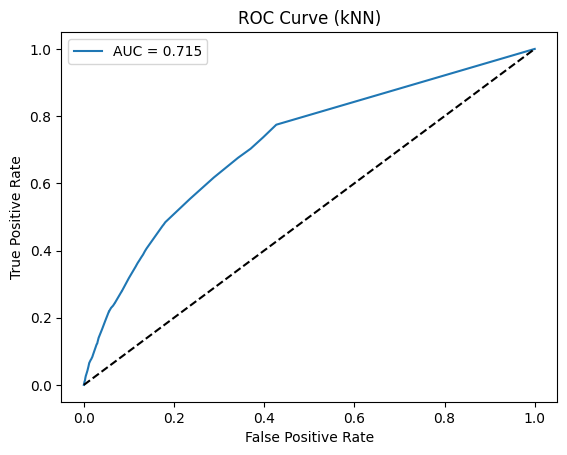

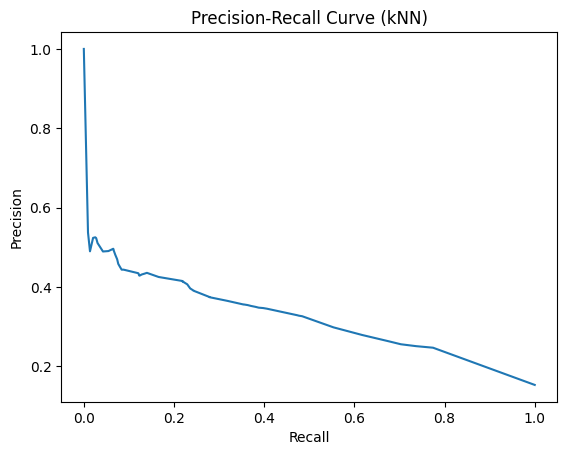

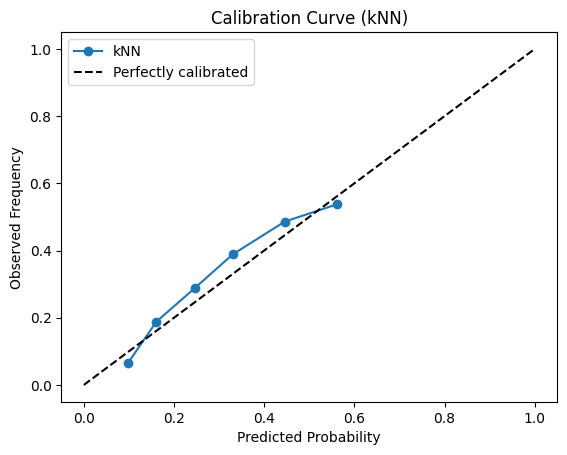

In [ ]:
# ROC Curve
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn_cal)
roc_auc_knn = roc_auc_score(y_test, y_prob_knn_cal)

plt.figure()
plt.plot(fpr_knn, tpr_knn, label=f"AUC = {roc_auc_knn:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve (kNN)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Precision-Recall Curve
precision_knn, recall_knn_curve, _ = precision_recall_curve(y_test, y_prob_knn_cal)

plt.figure()
plt.plot(recall_knn_curve, precision_knn)
plt.title("Precision-Recall Curve (kNN)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# Calibration Curve / Reliability Diagram
prob_true_knn, prob_pred_knn = calibration_curve(y_test, y_prob_knn_cal, n_bins=10)

plt.figure()
plt.plot(prob_pred_knn, prob_true_knn, marker='o', label='kNN')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.title("Calibration Curve (kNN)")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.legend()
plt.show()


# Model #3: Decision Tree Model

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_recall_curve,
    roc_curve, classification_report, recall_score
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import seaborn as sns

# stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    stratify=y_final,
    random_state=42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:")
print(y_train.value_counts(normalize=True))
print("Test class balance:")
print(y_test.value_counts(normalize=True))


pipe_tree = Pipeline([
    ('scaler', StandardScaler()),
    ('tree', DecisionTreeClassifier(random_state=42))
])

param_grid_tree = {
    'tree__max_depth': [4, 6, 8, 10],
    'tree__min_samples_split': [50, 100],
    'tree__min_samples_leaf': [25, 50]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_tree = GridSearchCV(
    estimator=pipe_tree,
    param_grid=param_grid_tree,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

print("Best Decision Tree Parameters:", grid_tree.best_params_)
print("Best CV F1 Score (Decision Tree):", grid_tree.best_score_)

best_tree = grid_tree.best_estimator_


Train shape: (183579, 21)  Test shape: (45895, 21)
Train class balance:
Diabetes_binary
0    0.847052
1    0.152948
Name: proportion, dtype: float64
Test class balance:
Diabetes_binary
0    0.847064
1    0.152936
Name: proportion, dtype: float64
Best Decision Tree Parameters: {'tree__max_depth': 4, 'tree__min_samples_leaf': 25, 'tree__min_samples_split': 50}
Best CV F1 Score (Decision Tree): 0.27056313370987256


In [ ]:
y_pred_tree = best_tree.predict(X_test)
y_prob_tree = best_tree.predict_proba(X_test)[:, 1]

acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree Test Accuracy:", acc_tree)
print("Decision Tree Test F1:", f1_tree)
print("Decision Tree Test Recall:", recall_tree)
print("Decision Tree Test ROC-AUC:", roc_auc_tree)
print("Classification report (Decision Tree):")
print(classification_report(y_test, y_pred_tree))

results_tree = pd.DataFrame({
    "Model": ["Decision Tree"],
    "CV_F1": [grid_tree.best_score_],
    "Test_Accuracy": [acc_tree],
    "Test_F1": [f1_tree],
    "Test_Recall": [recall_tree],
    "Test_ROC_AUC": [roc_auc_tree]
})
print(results_tree)


Decision Tree Test Accuracy: 0.8505501688637106
Decision Tree Test F1: 0.2903259182617693
Decision Tree Test Recall: 0.19988602365009261
Decision Tree Test ROC-AUC: 0.7816881338836874
Classification report (Decision Tree):
              precision    recall  f1-score   support

           0       0.87      0.97      0.92     38876
           1       0.53      0.20      0.29      7019

    accuracy                           0.85     45895
   macro avg       0.70      0.58      0.60     45895
weighted avg       0.82      0.85      0.82     45895

           Model     CV_F1  Test_Accuracy   Test_F1  Test_Recall  Test_ROC_AUC
0  Decision Tree  0.270563        0.85055  0.290326     0.199886      0.781688


                 Feature  Importance
0                 HighBP    0.457034
13               GenHlth    0.296232
3                    BMI    0.146756
1               HighChol    0.069944
18                   Age    0.030034
4                 Smoker    0.000000
2              CholCheck    0.000000
5                 Stroke    0.000000
6   HeartDiseaseorAttack    0.000000
9                Veggies    0.000000


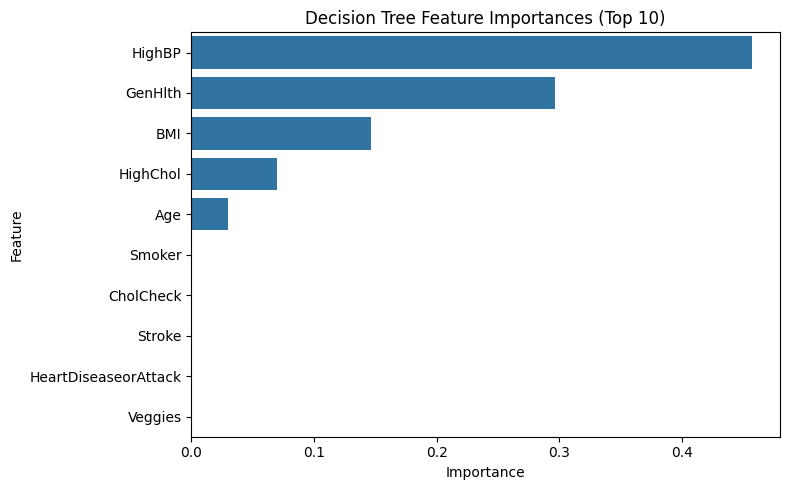

In [ ]:
# feature importance plot
tree_clf = best_tree.named_steps['tree']
importances = tree_clf.feature_importances_
feature_names = X_final.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp.head(10), x='Importance', y='Feature')
plt.title("Decision Tree Feature Importances (Top 10)")
plt.tight_layout()
plt.show()


In [ ]:
# calibration
cal_tree = CalibratedClassifierCV(
    estimator=best_tree,
    cv=3,
    method='sigmoid'
)

cal_tree.fit(X_train, y_train)
y_prob_tree_cal = cal_tree.predict_proba(X_test)[:, 1]


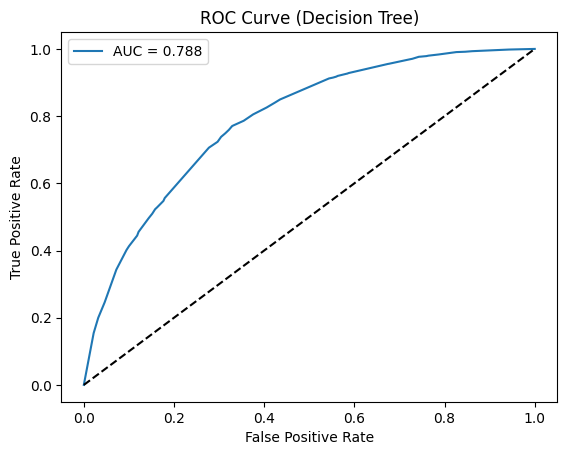

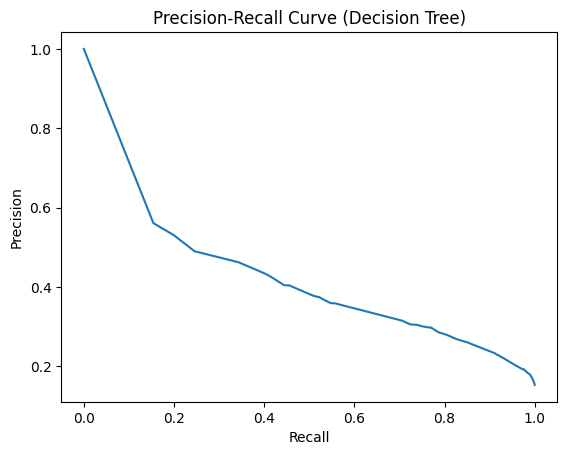

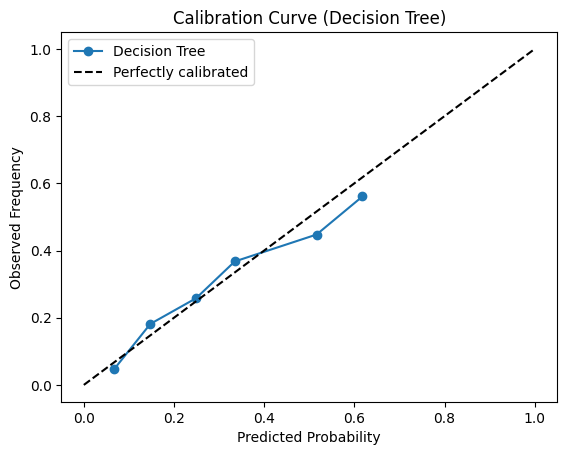

In [ ]:
# ROC Curve
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree_cal)
roc_auc_tree_cal = roc_auc_score(y_test, y_prob_tree_cal)

plt.figure()
plt.plot(fpr_tree, tpr_tree, label=f"AUC = {roc_auc_tree_cal:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve (Decision Tree)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Precision-Recall Curve
precision_tree, recall_tree_curve, _ = precision_recall_curve(y_test, y_prob_tree_cal)

plt.figure()
plt.plot(recall_tree_curve, precision_tree)
plt.title("Precision-Recall Curve (Decision Tree)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# Calibration Curve / Reliability Diagram
prob_true_tree, prob_pred_tree = calibration_curve(y_test, y_prob_tree_cal, n_bins=10)

plt.figure()
plt.plot(prob_pred_tree, prob_true_tree, marker='o', label='Decision Tree')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.title("Calibration Curve (Decision Tree)")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.legend()
plt.show()


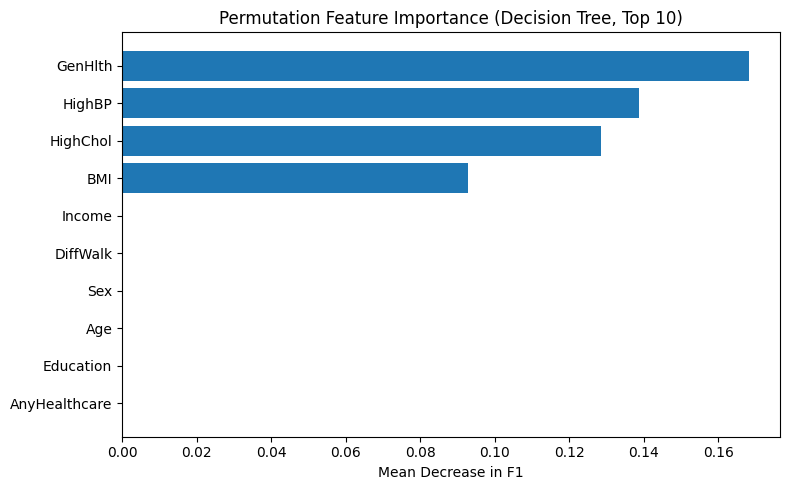

In [ ]:
# permutation
if len(X_test) > 5000:
    test_sample = X_test.sample(n=5000, random_state=42)
    y_test_sample = y_test.loc[test_sample.index]
else:
    test_sample = X_test
    y_test_sample = y_test

perm_tree = permutation_importance(
    estimator=cal_tree,
    X=test_sample,
    y=y_test_sample,
    n_repeats=3,
    random_state=42,
    n_jobs=-1,
    scoring='f1'
)

sorted_idx = perm_tree.importances_mean.argsort()[-10:]
top_features_perm = np.array(X_final.columns)[sorted_idx]

plt.figure(figsize=(8, 5))
plt.barh(top_features_perm, perm_tree.importances_mean[sorted_idx])
plt.title("Permutation Feature Importance (Decision Tree, Top 10)")
plt.xlabel("Mean Decrease in F1")
plt.tight_layout()
plt.show()


# Results

In [ ]:
# logistic regression metrics

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score

# best LR pipeline from GridSearchCV
best_lr = grid_lr.best_estimator_

# evaluate on the same test set
y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Test Accuracy:", acc_lr)
print("Logistic Regression Test F1:", f1_lr)
print("Logistic Regression Test Recall:", recall_lr)
print("Logistic Regression Test ROC-AUC:", roc_auc_lr)

results_lr = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "CV_F1": [grid_lr.best_score_],
    "Test_Accuracy": [acc_lr],
    "Test_F1": [f1_lr],
    "Test_Recall": [recall_lr],
    "Test_ROC_AUC": [roc_auc_lr]
})
print(results_lr)


Logistic Regression Test Accuracy: 0.8508770018520536
Logistic Regression Test F1: 0.24174606691779305
Logistic Regression Test Recall: 0.15543524718620885
Logistic Regression Test ROC-AUC: 0.8014519271629674
                 Model     CV_F1  Test_Accuracy   Test_F1  Test_Recall  \
0  Logistic Regression  0.222481       0.850877  0.241746     0.155435   

   Test_ROC_AUC  
0      0.801452  


In [ ]:
# combined model comparison table
model_comparison = pd.concat(
    [results_lr, results_knn, results_tree],
    ignore_index=True
)

print("Model Comparison Table:")
print(model_comparison)

model_comparison_sorted = model_comparison.sort_values(by="Test_F1", ascending=False)
print("Sorted by Test F1:")
print(model_comparison_sorted)


Model Comparison Table:
                 Model     CV_F1  Test_Accuracy   Test_F1  Test_Recall  \
0  Logistic Regression  0.222481       0.850877  0.241746     0.155435   
1                  kNN  0.275903       0.819131  0.291179     0.242912   
2        Decision Tree  0.270563       0.850550  0.290326     0.199886   

   Test_ROC_AUC  Best_k  
0      0.801452     NaN  
1      0.666143     3.0  
2      0.781688     NaN  
Sorted by Test F1:
                 Model     CV_F1  Test_Accuracy   Test_F1  Test_Recall  \
1                  kNN  0.275903       0.819131  0.291179     0.242912   
2        Decision Tree  0.270563       0.850550  0.290326     0.199886   
0  Logistic Regression  0.222481       0.850877  0.241746     0.155435   

   Test_ROC_AUC  Best_k  
1      0.666143     3.0  
2      0.781688     NaN  
0      0.801452     NaN  


In [ ]:
# summary table of cross-validated scores and best parameters
summary_cv = pd.DataFrame({
    "Model": ["Logistic Regression", "kNN", "Decision Tree"],
    "Best_Params": [
        grid_lr.best_params_,
        grid_knn.best_params_,
        grid_tree.best_params_
    ],
    "CV_F1": [
        grid_lr.best_score_,
        grid_knn.best_score_,
        grid_tree.best_score_
    ]
})

print("Cross-Validation Summary Table:")
print(summary_cv)


Cross-Validation Summary Table:
                 Model                                        Best_Params  \
0  Logistic Regression         {'logreg__C': 10, 'logreg__penalty': 'l2'}   
1                  kNN                            {'knn__n_neighbors': 3}   
2        Decision Tree  {'tree__max_depth': 4, 'tree__min_samples_leaf...   

      CV_F1  
0  0.222481  
1  0.275903  
2  0.270563  


# Diabetes class breakdowns by demographics

In [ ]:
# diabetes class breakdowns by demographics

full_df = df.copy()

# helper to compute prevalence (% with diabetes) for a given column
def diabetes_by_group(data, col):
    grp = data.groupby(col)['Diabetes_binary'].agg(
        prevalence='mean',
        count='size'
    ).reset_index()
    grp['prevalence'] = grp['prevalence'] * 100.0
    return grp

# by Sex
sex_breakdown = diabetes_by_group(full_df, 'Sex')
print("Diabetes breakdown by Sex:")
print(sex_breakdown)

# by Age group
age_breakdown = diabetes_by_group(full_df, 'Age')
print("Diabetes breakdown by Age:")
print(age_breakdown)

# by Education
edu_breakdown = diabetes_by_group(full_df, 'Education')
print("Diabetes breakdown by Education:")
print(edu_breakdown)

# by Income
inc_breakdown = diabetes_by_group(full_df, 'Income')
print("Diabetes breakdown by Income:")
print(inc_breakdown)


Diabetes breakdown by Sex:
   Sex  prevalence   count
0    0   14.252418  128715
1    1   16.625810  100759
Diabetes breakdown by Age:
    Age  prevalence  count
0     1    1.415351   5511
1     2    1.981880   7064
2     3    3.132795  10023
3     4    5.110802  12229
4     5    7.471510  14040
5     6   10.075231  17280
6     7   13.286623  23121
7     8   15.550748  27272
8     9   19.142125  29678
9    10   22.283711  29093
10   11   23.143728  21993
11   12   21.997529  15379
12   13   19.057829  16791
Diabetes breakdown by Education:
   Education  prevalence  count
0          1   27.011494    174
1          2   29.282178   4040
2          3   24.252667   9467
3          4   18.048557  61124
4          5   15.518331  66444
5          6   11.593086  88225
Diabetes breakdown by Income:
   Income  prevalence  count
0       1   24.338678   9791
1       2   26.250425  11756
2       3   22.386935  15920
3       4   20.282664  19953
4       5   17.724868  25326
5       6   15.047058  349

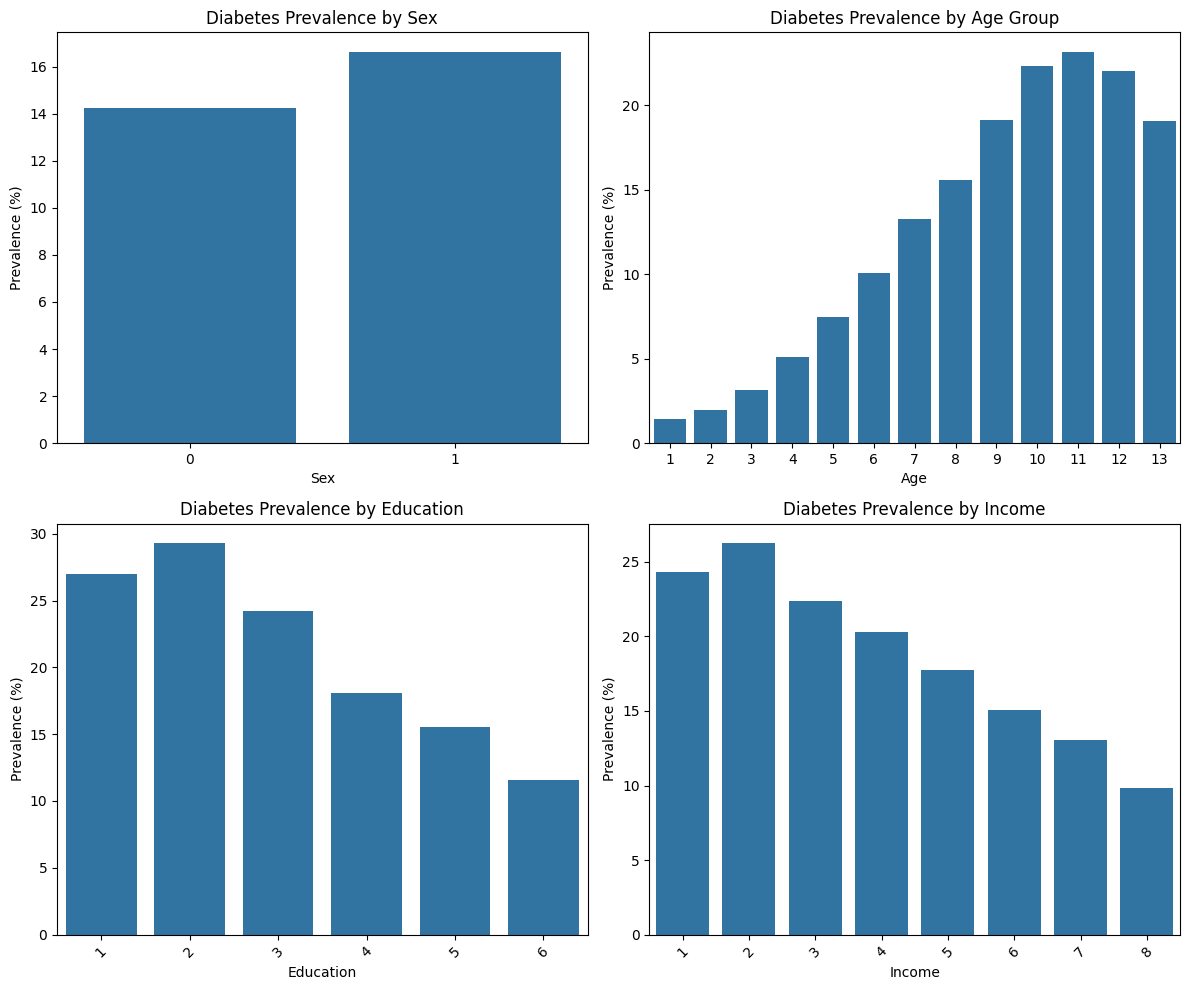

In [ ]:
# visualizations based on demographics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.barplot(data=sex_breakdown, x='Sex', y='prevalence', ax=axes[0, 0])
axes[0, 0].set_title("Diabetes Prevalence by Sex")
axes[0, 0].set_ylabel("Prevalence (%)")

sns.barplot(data=age_breakdown, x='Age', y='prevalence', ax=axes[0, 1])
axes[0, 1].set_title("Diabetes Prevalence by Age Group")
axes[0, 1].set_ylabel("Prevalence (%)")

sns.barplot(data=edu_breakdown, x='Education', y='prevalence', ax=axes[1, 0])
axes[1, 0].set_title("Diabetes Prevalence by Education")
axes[1, 0].set_ylabel("Prevalence (%)")
axes[1, 0].tick_params(axis='x', rotation=45)

sns.barplot(data=inc_breakdown, x='Income', y='prevalence', ax=axes[1, 1])
axes[1, 1].set_title("Diabetes Prevalence by Income")
axes[1, 1].set_ylabel("Prevalence (%)")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# Summary figures for model comparison + key variables influencing risk

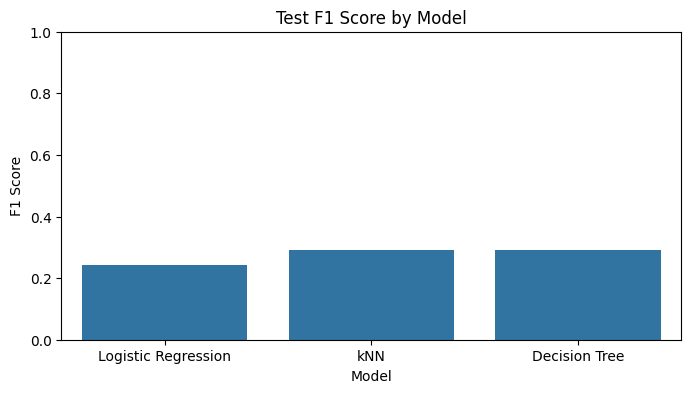

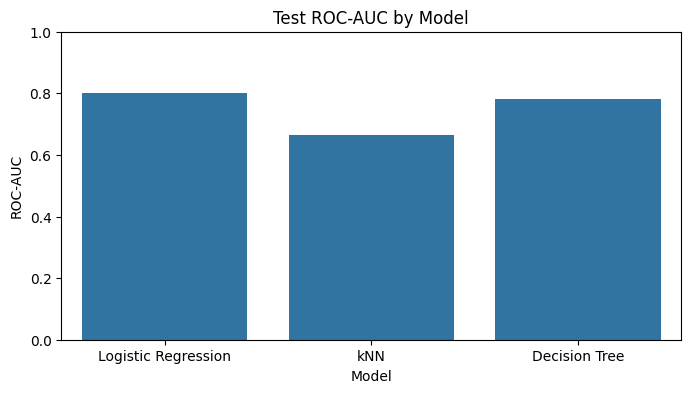

In [ ]:
# model comparison bar plots for F1 and AUC
plt.figure(figsize=(8, 4))
sns.barplot(data=model_comparison, x='Model', y='Test_F1')
plt.title("Test F1 Score by Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=model_comparison, x='Model', y='Test_ROC_AUC')
plt.title("Test ROC-AUC by Model")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.show()


Top 10 features by |logistic coefficient|:
                 Feature  Coefficient  AbsCoeff
13               GenHlth     0.532999  0.532999
3                    BMI     0.396487  0.396487
18                   Age     0.373107  0.373107
0                 HighBP     0.366516  0.366516
1               HighChol     0.279209  0.279209
2              CholCheck     0.251725  0.251725
10     HvyAlcoholConsump    -0.190694  0.190694
17                   Sex     0.130021  0.130021
20                Income    -0.092920  0.092920
6   HeartDiseaseorAttack     0.065345  0.065345


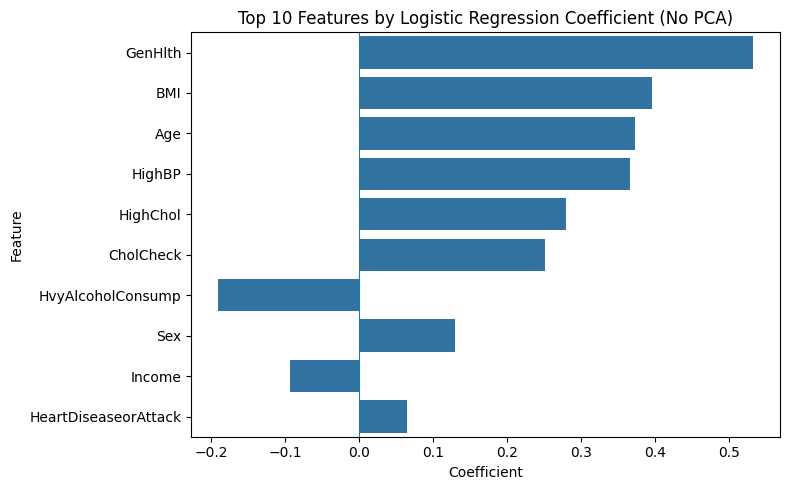

In [ ]:
# key variables influencing diabetes risk
# scale + logistic regression
pipe_lr_nopca = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        C=grid_lr.best_params_['logreg__C'],  # best C from PCA model
        penalty='l2',
        max_iter=500,
        solver='lbfgs'
    ))
])

# fit on the same training data
pipe_lr_nopca.fit(X_train, y_train)

# extract coefficients aligned with original features
logreg_nopca = pipe_lr_nopca.named_steps['logreg']
coef = logreg_nopca.coef_[0]

coef_df = pd.DataFrame({
    'Feature': X_final.columns,
    'Coefficient': coef,
    'AbsCoeff': np.abs(coef)
}).sort_values(by='AbsCoeff', ascending=False)

print("Top 10 features by |logistic coefficient|:")
print(coef_df.head(10))

plt.figure(figsize=(8, 5))
sns.barplot(
    data=coef_df.head(10),
    x='Coefficient',
    y='Feature'
)
plt.title("Top 10 Features by Logistic Regression Coefficient (No PCA)")
plt.axvline(0, linewidth=0.8)
plt.tight_layout()
plt.show()


# Best Model based on test F1 and AUC

In [ ]:
best_by_f1 = model_comparison.sort_values(
    by=["Test_F1", "Test_ROC_AUC"],
    ascending=False
).iloc[0]

print("Best model based on Test F1 (with AUC tiebreaker):")
print(best_by_f1)

Best model based on Test F1 (with AUC tiebreaker):
Model                 kNN
CV_F1            0.275903
Test_Accuracy    0.819131
Test_F1          0.291179
Test_Recall      0.242912
Test_ROC_AUC     0.666143
Best_k                3.0
Name: 1, dtype: object


# Initial Results

- kNN had the highest F1 score, meaning it achieved the best balance between precision and recall among the three models.

- Logistic regression shows steady but not a great performance. Accuracy is high because the data is imbalanced, not because the model is perfect. F1 and recall are only moderate, so the model still misses many diabetes cases. The ROC-AUC is clearly above 0.5, which means it is learning real signal. The calibration curve looks reasonable, so its predicted probabilities are usable. The main drivers it highlights are general health, BMI, age, high blood pressure, and prior heart disease.

- kNN achieves the highest F1 score on the test set, so under our selection rule it is the “best” model. Its accuracy is similar to logistic regression, and its ROC-AUC is in the mid-0.6 range, so ranking quality is not much better. The best configuration uses k = 3 neighbors. Its feature importance pattern (from permutation importance) points to the same key variables as logistic regression. However, kNN is harder to interpret and slower to run, so it is more useful as a performance benchmark than as a practical model.

- The decision tree performs the worst on F1 and ROC-AUC. Its accuracy looks acceptable, but again that is largely due to class imbalance. It misses more positive diabetes cases than logistic regression and kNN. Limiting the depth and leaf size controls overfitting but also reduces the model’s flexibility. The tree still highlights the same core risk factors as the other models. Its main value is that it provides simple, human-readable rules rather than top predictive performance.

- When we compare models, accuracy is similar across the board and not very informative. F1 and ROC-AUC are more meaningful in this setting. kNN has the highest F1, while logistic regression is competitive or better on ROC-AUC and clearly better calibrated. The decision tree lags behind both on these metrics. The comparison tables and bar plots make these differences clear.

- Cross-validation F1 scores are lower than the single test F1 scores for all models. This suggests that the test split is well, but the gap is not extreme. Logistic regression and kNN are close in cross-validated performance. The decision tree has the lowest cross-validated F1.

- The demographic results show that diabetes prevalence rises sharply with age. Older groups have much higher rates than younger adults. Lower education levels and lower income groups also show higher prevalence than more advantaged groups. Sex differences exist but are smaller than the age and socioeconomic patterns. These patterns match the variables that the models treat as most important.

- Overall, all three methods agree on the main signals/trends in the data. General health, BMI, age, blood pressure, and heart disease history consistently appear as key predictors.


